# Experiment Results Plotting

This notebook loads saved experiment results without retraining models or loading graph data.

The first section compares the two `ablation_analysis` datasets:

- **Day 3.5**: `timepoint_filter_mode="day3p5"`
- **Day 4.5**: `timepoint_filter_mode="rest"`

Center-resolved effects are displayed with matched color scales across timepoints. Population-ablation curves overlay both timepoints in the same marker-resolved figures, including standard-error bands.

In [1]:
from __future__ import annotations

import json
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    current = current.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "experiments").is_dir():
            return candidate
    raise RuntimeError("Could not locate the GraphNN project root.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

## Settings

In [ ]:
# Set either path to a specific completed run directory to disable auto-discovery.
ABLATION_RUN_DIRS = {
    "Day 3.5": PROJECT_ROOT / "results_experiments/ablation_analysis/folded_depth4_20260610_131745",
    "Day 4.5": PROJECT_ROOT / "results_experiments/ablation_analysis/folded_depth4_20260610_101834",
}

ABLATION_TIMEPOINT_MODES = {
    "Day 3.5": "day3p5",
    "Day 4.5": "rest",
}
ABLATION_RESULTS_ROOT = (
    PROJECT_ROOT / "results_experiments" / "ablation_analysis"
)

# Set to a completed lineage_removal run directory, or None to auto-discover
# the newest complete folded run. The current default discovers marker-isolation
# results if those are the newest lineage_removal outputs.
LINEAGE_RUN_DIR = None
LINEAGE_RESULTS_ROOT = (
    PROJECT_ROOT / "results_experiments" / "lineage_removal"
)
LINEAGE_REQUIRE_FOLDED = True
LINEAGE_ANALYSIS_VARIANT = None  # e.g. "marker_isolation", or None for latest
LINEAGE_REGION_ORDER = ["full", "crypt", "neck", "villus"]
LINEAGE_POINT_DEPTH = 2

# Auto-discovery selects the newest complete run for each mode. Requiring a
# common depth prevents accidental comparison of unlike receptive fields.
AUTO_DISCOVERY_REQUIRE_FOLDED = True
REQUIRE_MATCHED_MODEL_DEPTH = True

TIMEPOINT_COLORS = {
    "Day 3.5": "#4C78A8",
    "Day 4.5": "#E45756",
}
TIMEPOINT_ORDER = list(ABLATION_RUN_DIRS)

METRICS = {
    "delta_mu": {
        "label": r"$\Delta$ predicted curvature",
        "short": "curvature",
    },
    "delta_variance": {
        "label": r"$\Delta$ predicted variance",
        "short": "variance",
    },
    "delta_mse": {
        "label": r"$\Delta$ squared error",
        "short": "mse",
    },
}

N_PANEL_COLUMNS = 4
HEATMAP_MIN_CASES = None  # None uses the threshold saved by each run.
HEATMAP_CMAP = "RdBu_r"
FIGURE_DPI = 300

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
SAVE_DIR = (
    PROJECT_ROOT
    / "results_experiments"
    / "experiment_results_plotting"
    / f"ablation_timepoint_comparison_{RUN_TIMESTAMP}"
)
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## Result Loading

In [3]:
REQUIRED_ABLATION_TABLES = {
    "center": "center_resolved_effect_summary.csv",
    "population": "population_effect_summary.csv",
    "prevalence": "population_marker_prevalence.csv",
}


def load_json(path):
    with Path(path).open() as handle:
        return json.load(handle)


def result_settings_path(run_dir):
    run_dir = Path(run_dir)
    for name in ("settings.json", "config.json"):
        candidate = run_dir / name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"No settings.json or config.json in {run_dir}")


def is_complete_ablation_run(run_dir):
    run_dir = Path(run_dir)
    try:
        settings = load_json(result_settings_path(run_dir))
    except (FileNotFoundError, json.JSONDecodeError):
        return False
    tables_dir = run_dir / "tables"
    return all(
        (tables_dir / filename).exists()
        for filename in REQUIRED_ABLATION_TABLES.values()
    )


def discover_latest_ablation_run(timepoint_mode):
    candidates = []
    if not ABLATION_RESULTS_ROOT.exists():
        raise FileNotFoundError(ABLATION_RESULTS_ROOT)
    for run_dir in ABLATION_RESULTS_ROOT.iterdir():
        if not run_dir.is_dir() or not is_complete_ablation_run(run_dir):
            continue
        settings = load_json(result_settings_path(run_dir))
        mode = settings.get("filtering", {}).get("timepoint_filter_mode")
        analysis_mode = settings.get("analysis_mode")
        if mode != timepoint_mode:
            continue
        if AUTO_DISCOVERY_REQUIRE_FOLDED and analysis_mode != "folded":
            continue
        candidates.append(run_dir)
    if not candidates:
        raise FileNotFoundError(
            f"No complete ablation run found for mode={timepoint_mode!r}."
        )
    return max(candidates, key=lambda path: path.stat().st_mtime)


def load_ablation_run(run_dir, timepoint):
    run_dir = Path(run_dir).resolve()
    settings_path = result_settings_path(run_dir)
    settings = load_json(settings_path)
    tables = {
        key: pd.read_csv(run_dir / "tables" / filename)
        for key, filename in REQUIRED_ABLATION_TABLES.items()
    }
    return {
        "timepoint": timepoint,
        "run_dir": run_dir,
        "settings_path": settings_path,
        "settings": settings,
        "tables": tables,
    }


resolved_run_dirs = {}
for timepoint, configured_path in ABLATION_RUN_DIRS.items():
    resolved_run_dirs[timepoint] = (
        discover_latest_ablation_run(ABLATION_TIMEPOINT_MODES[timepoint])
        if configured_path is None
        else Path(configured_path).expanduser().resolve()
    )

ablation_runs = {
    timepoint: load_ablation_run(run_dir, timepoint)
    for timepoint, run_dir in resolved_run_dirs.items()
}

In [4]:
def marker_names_for_run(run):
    settings = run["settings"]
    names = settings.get("marker_names")
    if names is None:
        names = (
            run["tables"]["population"]
            .sort_values("source_marker")
            ["marker"]
            .drop_duplicates()
            .tolist()
        )
    return list(names)


run_summary_rows = []
for timepoint in TIMEPOINT_ORDER:
    run = ablation_runs[timepoint]
    settings = run["settings"]
    run_summary_rows.append({
        "timepoint": timepoint,
        "run_dir": str(run["run_dir"]),
        "analysis_mode": settings.get("analysis_mode"),
        "timepoint_filter_mode": settings.get("filtering", {}).get(
            "timepoint_filter_mode"
        ),
        "model_depth": settings.get("model", {}).get("num_layers"),
        "n_graphs_after_filtering": settings.get("n_graphs_after_filtering"),
        "population_weighting": settings.get("perturbation", {}).get(
            "population_weighting"
        ),
        "marker_names": "|".join(marker_names_for_run(run)),
    })
run_summary_df = pd.DataFrame(run_summary_rows)

depths = run_summary_df["model_depth"].dropna().unique()
if REQUIRE_MATCHED_MODEL_DEPTH and len(depths) != 1:
    raise ValueError(
        "Selected runs have different model depths: "
        f"{run_summary_df[['timepoint', 'model_depth']].to_dict('records')}"
    )

marker_orders = [marker_names_for_run(run) for run in ablation_runs.values()]
if any(names != marker_orders[0] for names in marker_orders[1:]):
    raise ValueError("Selected runs do not use the same marker order.")
marker_names = marker_orders[0]
model_depth = int(depths[0])

run_summary_df.to_csv(TABLES_DIR / "ablation_run_summary.csv", index=False)
display(run_summary_df)

,timepoint,run_dir,analysis_mode,timepoint_filter_mode,model_depth,n_graphs_after_filtering,population_weighting,marker_names
0,Day 3.5,/home/fmoller/Projects/LearningOrganoids/Graph...,folded,day3p5,4,141,organoid,Agr2|AldoB|Chroma|KI67|LGR5|Lysozyme|Serotonin
1,Day 4.5,/home/fmoller/Projects/LearningOrganoids/Graph...,folded,rest,4,706,organoid,Agr2|AldoB|Chroma|KI67|LGR5|Lysozyme|Serotonin


In [5]:
def add_run_identity(table, timepoint, run_dir):
    result = table.copy()
    result.insert(0, "timepoint", timepoint)
    result.insert(1, "run_dir", str(run_dir))
    return result


center_summary_df = pd.concat(
    [
        add_run_identity(
            ablation_runs[timepoint]["tables"]["center"],
            timepoint,
            ablation_runs[timepoint]["run_dir"],
        )
        for timepoint in TIMEPOINT_ORDER
    ],
    ignore_index=True,
)
population_summary_df = pd.concat(
    [
        add_run_identity(
            ablation_runs[timepoint]["tables"]["population"],
            timepoint,
            ablation_runs[timepoint]["run_dir"],
        )
        for timepoint in TIMEPOINT_ORDER
    ],
    ignore_index=True,
)
prevalence_summary_df = pd.concat(
    [
        add_run_identity(
            ablation_runs[timepoint]["tables"]["prevalence"],
            timepoint,
            ablation_runs[timepoint]["run_dir"],
        )
        for timepoint in TIMEPOINT_ORDER
    ],
    ignore_index=True,
)

center_summary_df.to_csv(
    TABLES_DIR / "combined_center_resolved_effect_summary.csv", index=False
)
population_summary_df.to_csv(
    TABLES_DIR / "combined_population_effect_summary.csv", index=False
)
prevalence_summary_df.to_csv(
    TABLES_DIR / "combined_population_marker_prevalence.csv", index=False
)

In [6]:
def safe_filename(name):
    text = str(name).strip().replace("/", "_")
    cleaned = "".join(
        char if char.isalnum() or char in "._-" else "_"
        for char in text
    ).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def save_figure(fig, name):
    stem = safe_filename(name)
    for suffix in ("pdf", "png"):
        fig.savefig(
            FIGURES_DIR / f"{stem}.{suffix}",
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

## Center-Resolved Ablation

Rows correspond to timepoints and columns to hop distances. The color scale is shared across every panel for a given metric. Cells below the saved minimum case threshold are white.

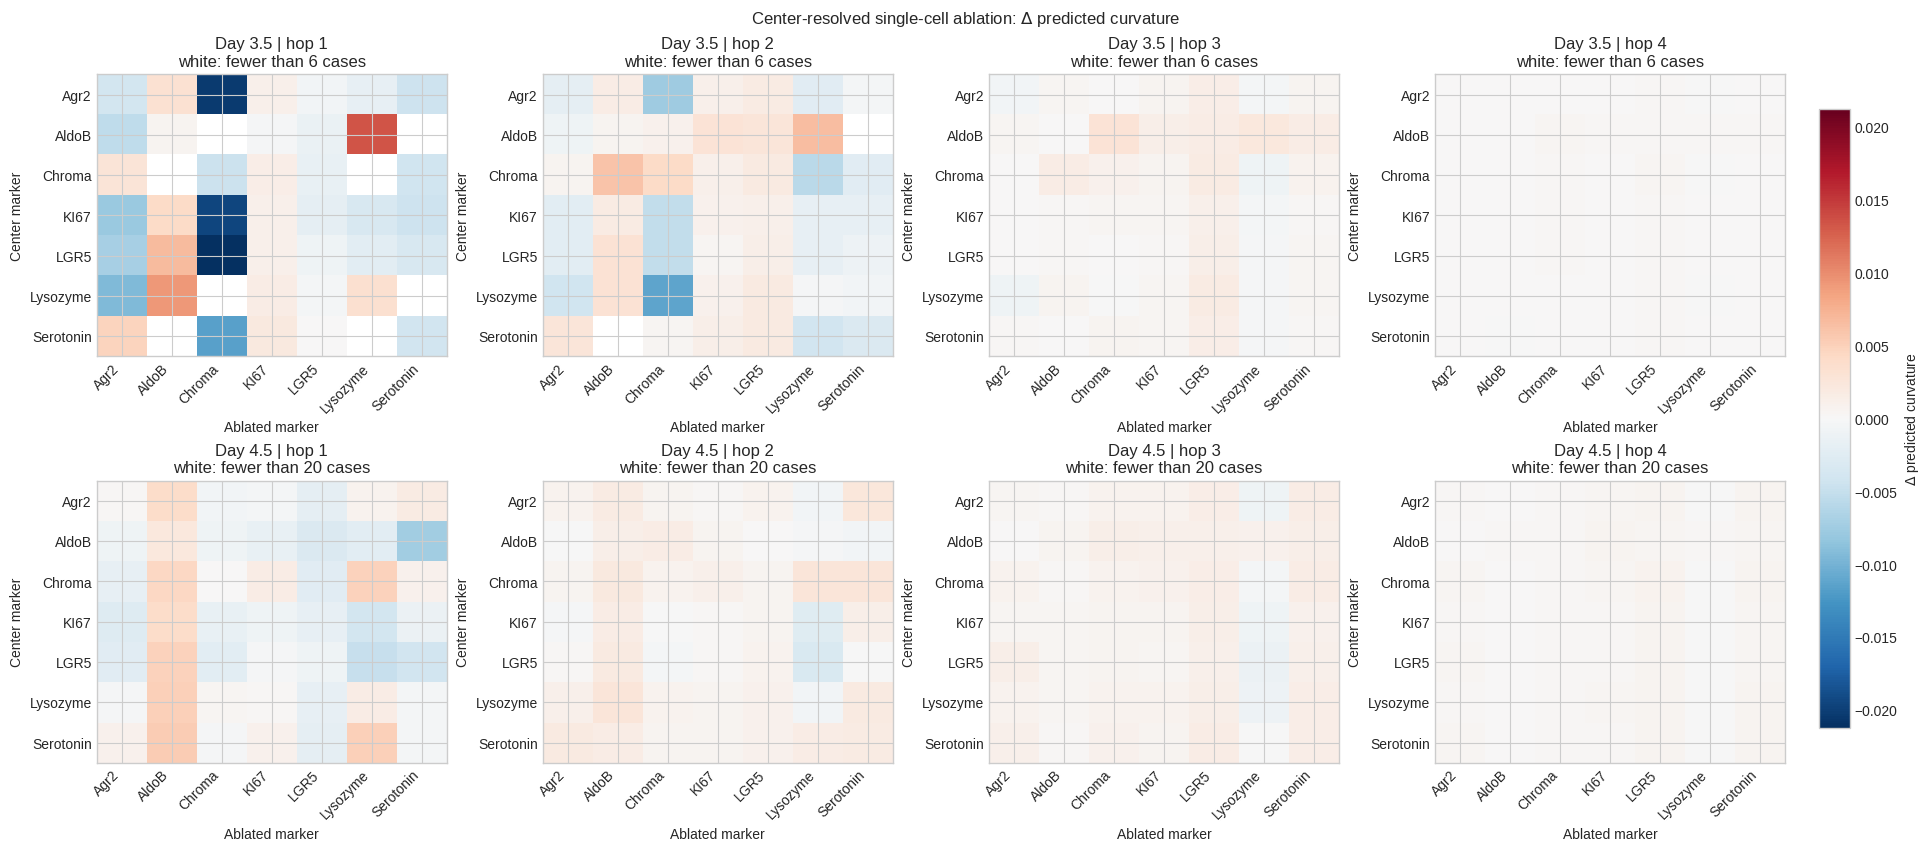

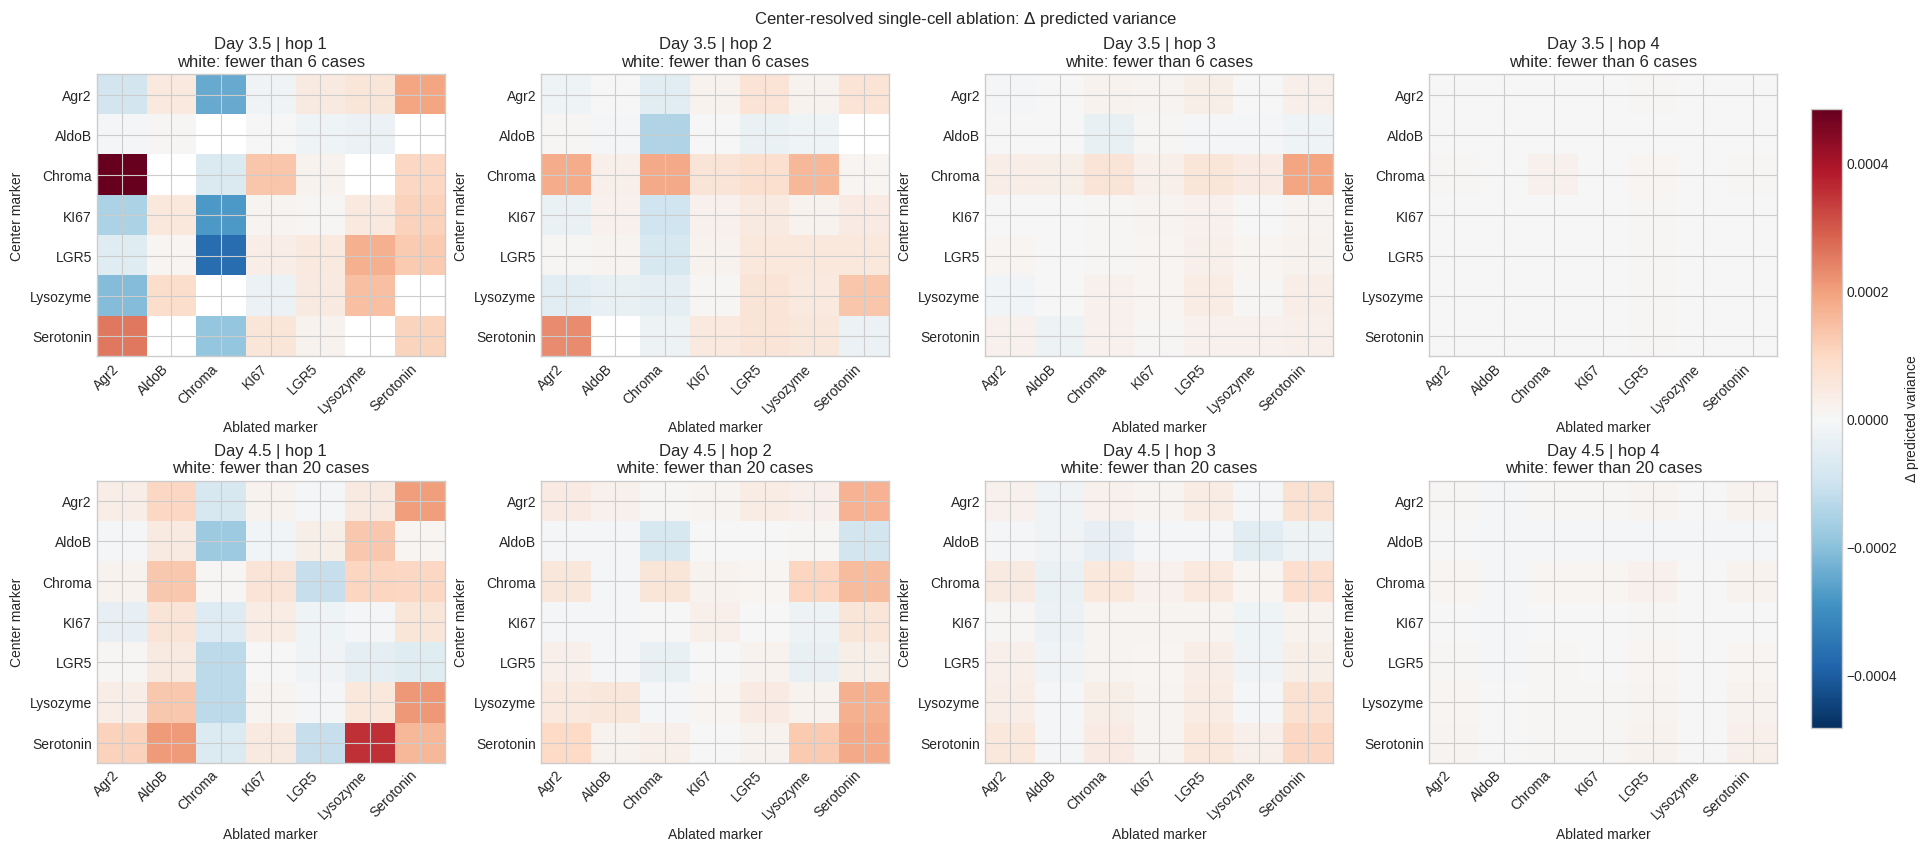

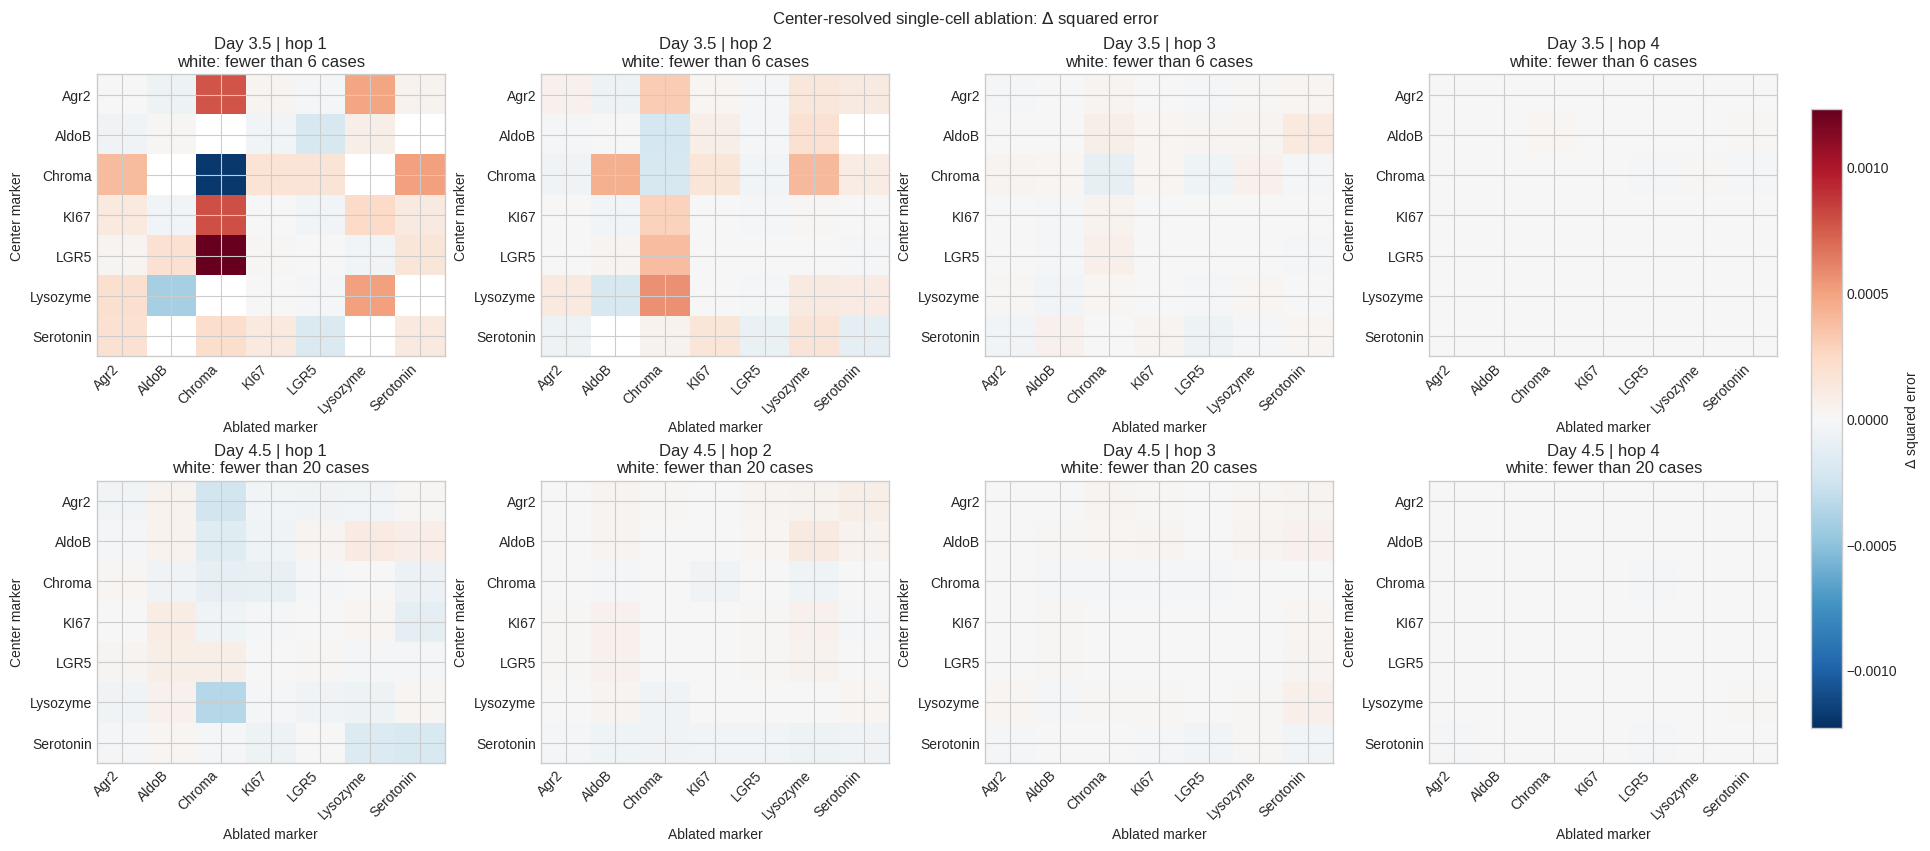

In [7]:
def center_resolved_matrix(summary, metric, hop, marker_order):
    n_markers = len(marker_order)
    marker_to_index = {marker: index for index, marker in enumerate(marker_order)}
    values = np.full((n_markers, n_markers), np.nan, dtype=float)
    counts = np.zeros((n_markers, n_markers), dtype=int)
    subset = summary[
        (summary["metric"] == metric) & (summary["hop"] == int(hop))
    ]
    for row in subset.itertuples(index=False):
        if row.center_marker not in marker_to_index:
            continue
        center_index = marker_to_index[row.center_marker]
        source_index = int(row.source_marker)
        if 0 <= source_index < n_markers:
            values[center_index, source_index] = float(row.mean_effect)
            counts[center_index, source_index] = int(row.cases)
    return values, counts


def heatmap_min_cases_for_run(run):
    if HEATMAP_MIN_CASES is not None:
        return int(HEATMAP_MIN_CASES)
    return int(
        run["settings"]
        .get("perturbation", {})
        .get("heatmap_display_min_cases", 1)
    )


def plot_center_resolved_timepoints(metric):
    hops = sorted(center_summary_df["hop"].dropna().astype(int).unique())
    panel_data = {}
    finite_values = []
    for timepoint in TIMEPOINT_ORDER:
        run_summary = center_summary_df[
            center_summary_df["timepoint"] == timepoint
        ]
        threshold = heatmap_min_cases_for_run(ablation_runs[timepoint])
        for hop in hops:
            values, counts = center_resolved_matrix(
                run_summary, metric, hop, marker_names
            )
            masked = values.copy()
            masked[counts < threshold] = np.nan
            panel_data[(timepoint, hop)] = (masked, counts, threshold)
            finite_values.extend(masked[np.isfinite(masked)].tolist())

    max_abs = max((abs(value) for value in finite_values), default=1.0)
    if max_abs == 0:
        max_abs = 1.0
    cmap = plt.get_cmap(HEATMAP_CMAP).copy()
    cmap.set_bad("white")

    fig, axes = plt.subplots(
        len(TIMEPOINT_ORDER),
        len(hops),
        figsize=(4.8 * len(hops), 4.2 * len(TIMEPOINT_ORDER)),
        squeeze=False,
        constrained_layout=True,
    )
    image = None
    for row_index, timepoint in enumerate(TIMEPOINT_ORDER):
        for column_index, hop in enumerate(hops):
            ax = axes[row_index, column_index]
            values, counts, threshold = panel_data[(timepoint, hop)]
            image = ax.imshow(
                np.ma.masked_invalid(values),
                cmap=cmap,
                vmin=-max_abs,
                vmax=max_abs,
                aspect="auto",
            )
            ax.set_title(
                f"{timepoint} | hop {hop}\n"
                f"white: fewer than {threshold} cases"
            )
            ax.set_xticks(np.arange(len(marker_names)))
            ax.set_xticklabels(marker_names, rotation=45, ha="right")
            ax.set_yticks(np.arange(len(marker_names)))
            ax.set_yticklabels(marker_names)
            ax.set_xlabel("Ablated marker")
            ax.set_ylabel("Center marker")
    colorbar = fig.colorbar(
        image,
        ax=list(axes.ravel()),
        location="right",
        shrink=0.90,
        pad=0.02,
    )
    colorbar.set_label(METRICS[metric]["label"])
    fig.suptitle(
        f"Center-resolved single-cell ablation: {METRICS[metric]['label']}"
    )
    save_figure(
        fig,
        f"center_resolved_timepoint_comparison_{METRICS[metric]['short']}",
    )
    plt.show()
    return fig, axes


for metric in METRICS:
    plot_center_resolved_timepoints(metric)

## Population Ablation

Each marker has its own panel. Day 3.5 and Day 4.5 are drawn together, and shading shows the standard error of the mean for each timepoint.

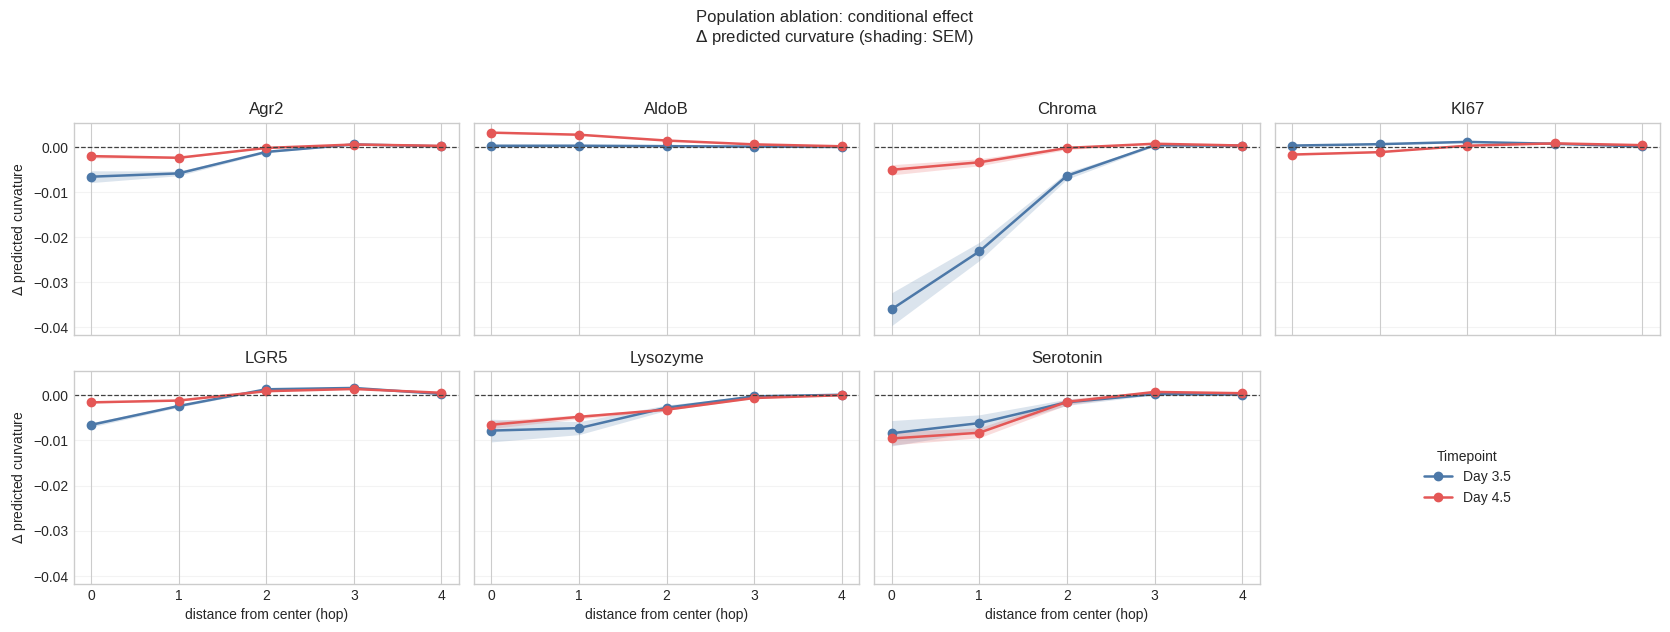

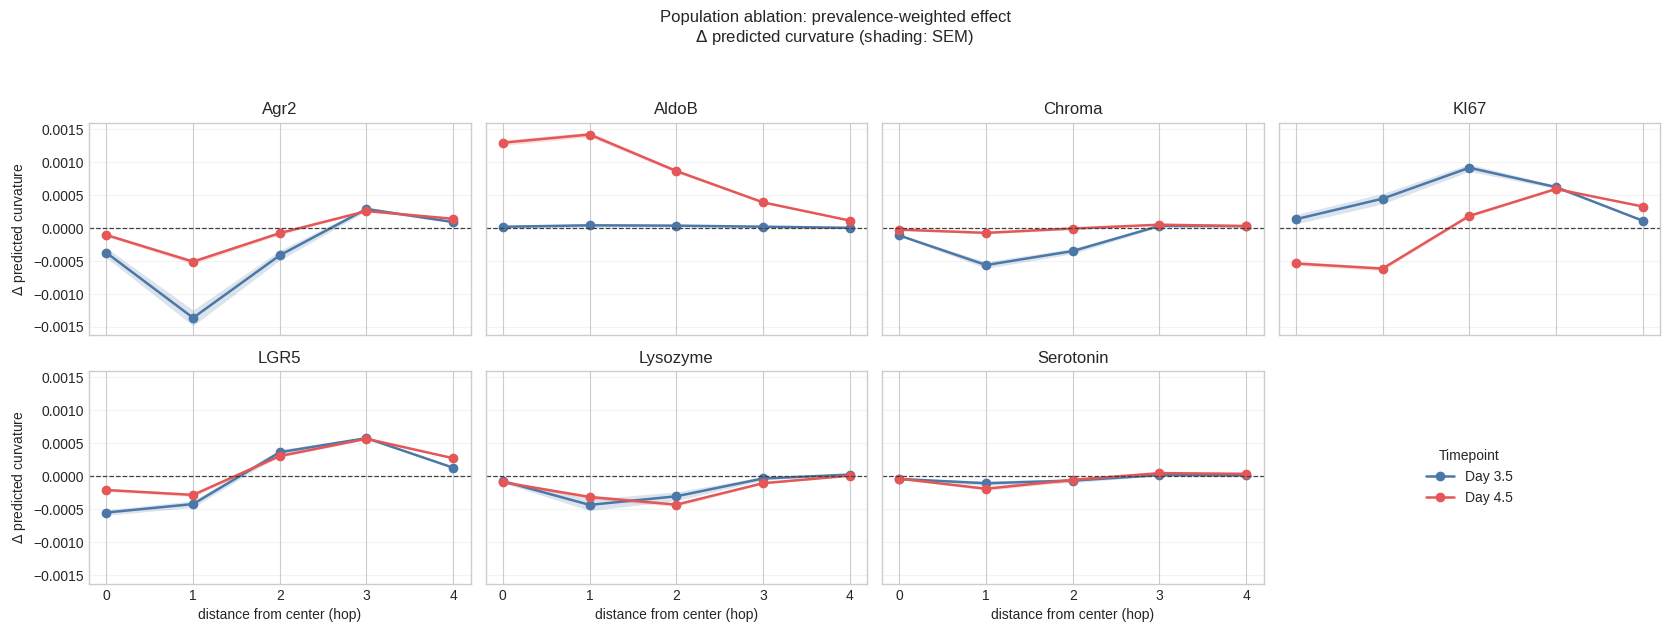

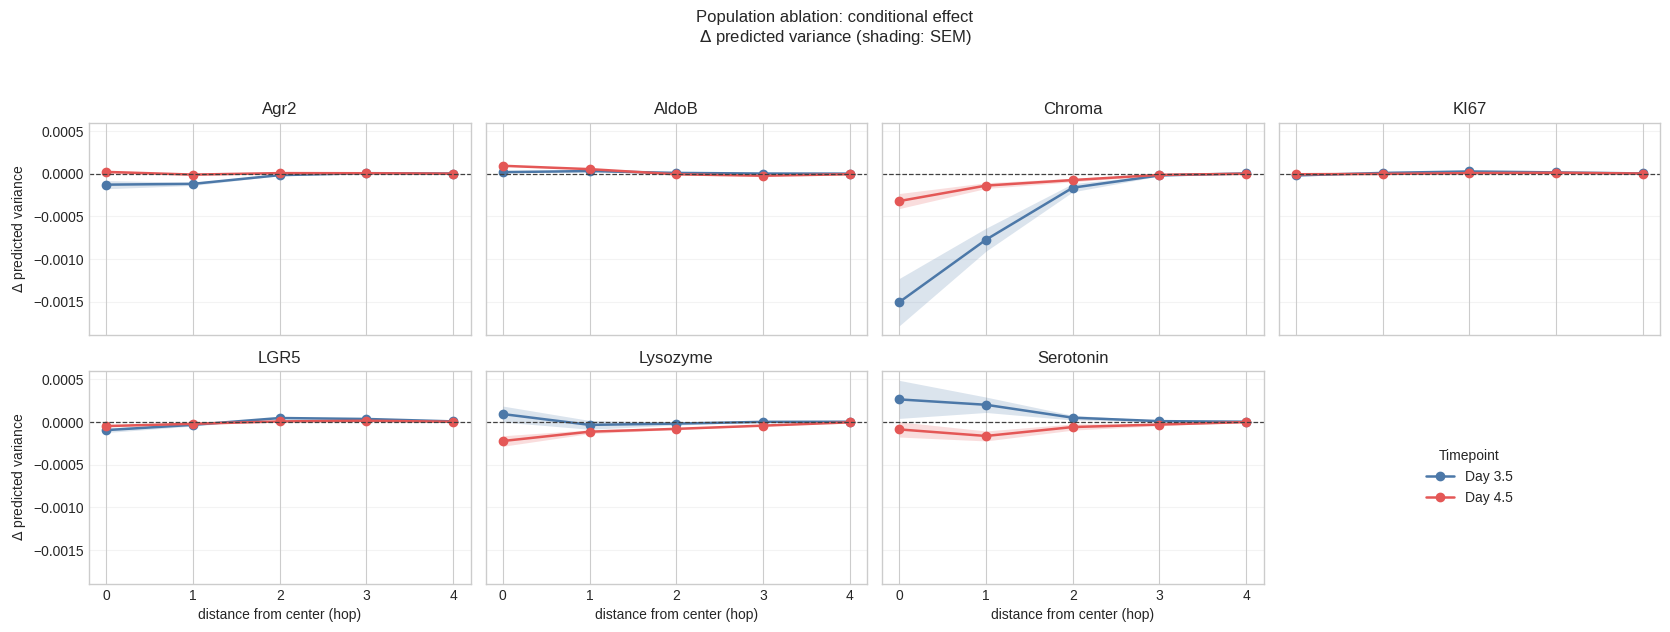

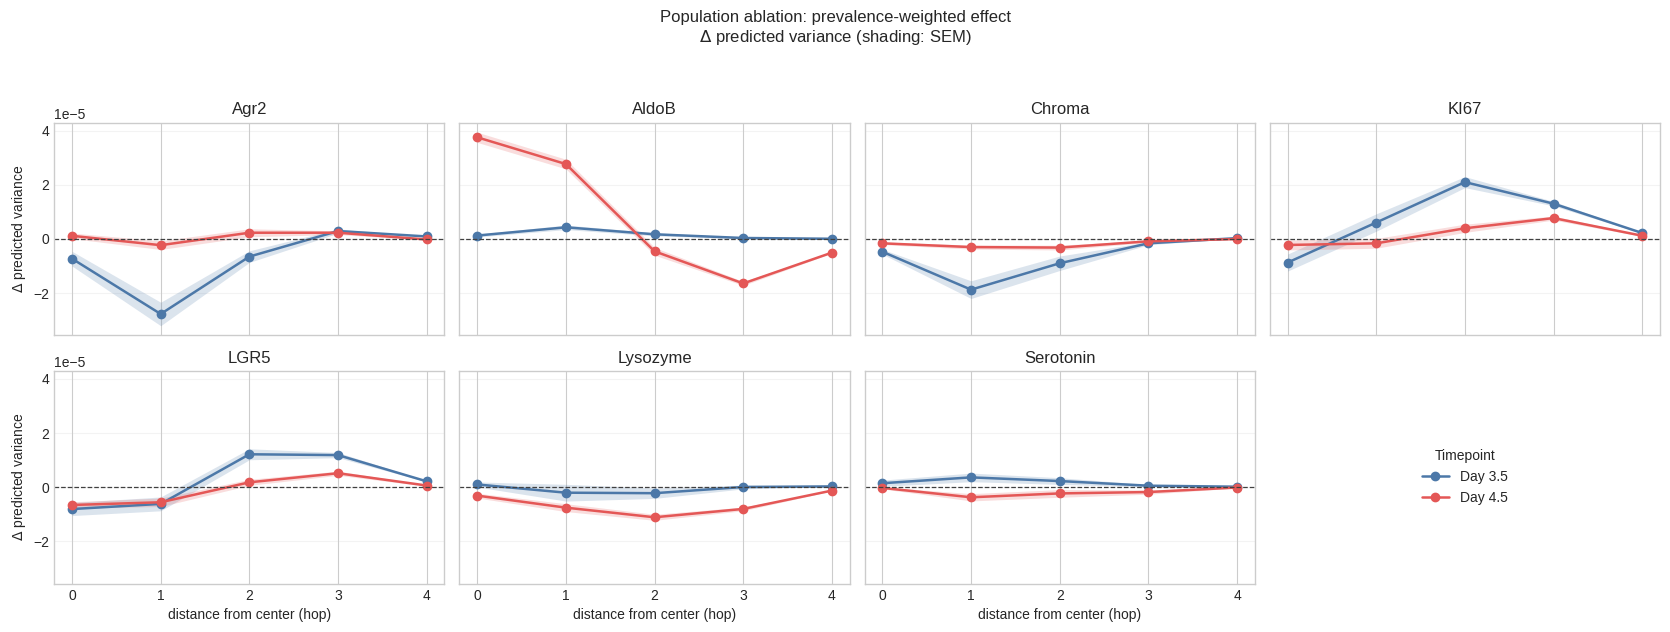

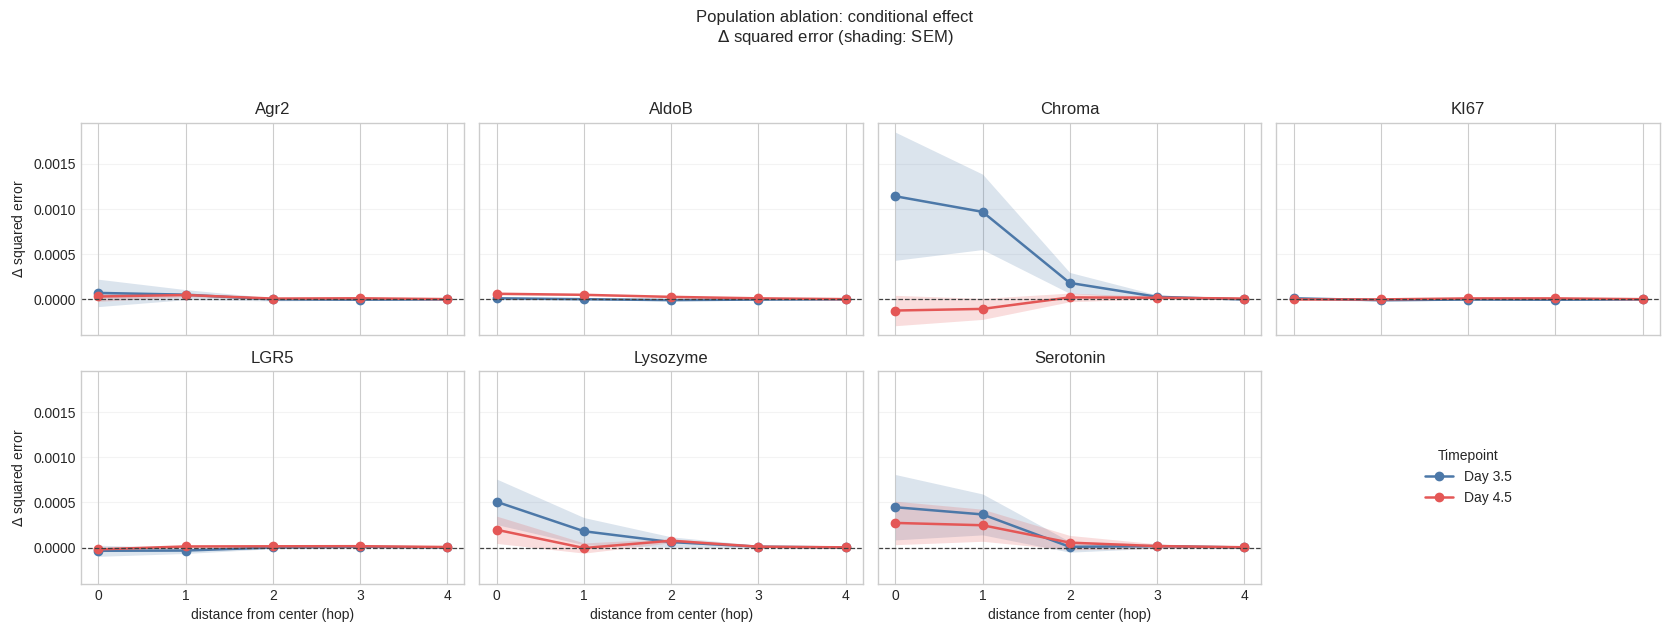

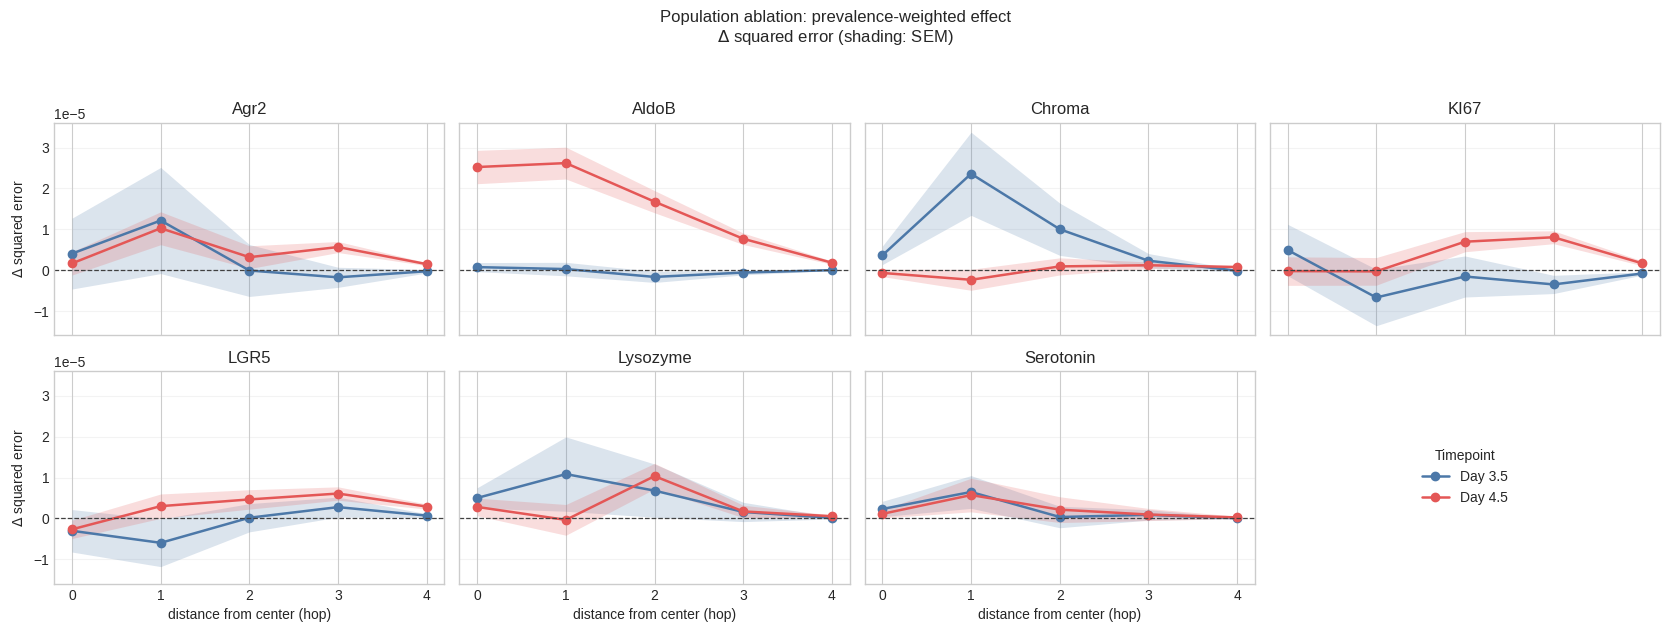

In [8]:
def plot_population_timepoint_comparison(
    metric,
    value_column,
    sem_column,
    estimand_label,
):
    metric_df = population_summary_df[
        population_summary_df["metric"] == metric
    ]
    n_rows = int(np.ceil(len(marker_names) / N_PANEL_COLUMNS))
    fig, axes = plt.subplots(
        n_rows,
        N_PANEL_COLUMNS,
        figsize=(4.2 * N_PANEL_COLUMNS, 3.2 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes_flat = axes.ravel()

    for ax, marker in zip(axes_flat, marker_names):
        for timepoint in TIMEPOINT_ORDER:
            marker_df = metric_df[
                (metric_df["marker"] == marker)
                & (metric_df["timepoint"] == timepoint)
            ].sort_values("hop")
            hops = marker_df["hop"].to_numpy(float)
            means = marker_df[value_column].to_numpy(float)
            sems = marker_df[sem_column].to_numpy(float)
            color = TIMEPOINT_COLORS[timepoint]
            ax.plot(
                hops,
                means,
                marker="o",
                linewidth=1.8,
                color=color,
                label=timepoint,
            )
            valid = (
                np.isfinite(hops)
                & np.isfinite(means)
                & np.isfinite(sems)
            )
            if np.any(valid):
                ax.fill_between(
                    hops[valid],
                    means[valid] - sems[valid],
                    means[valid] + sems[valid],
                    color=color,
                    alpha=0.20,
                    linewidth=0,
                )
        ax.axhline(0, color="0.25", linestyle="--", linewidth=0.9)
        ax.set_title(marker)
        ax.set_xticks(range(model_depth + 1))
        ax.grid(axis="y", alpha=0.22)

    unused_axes = axes_flat[len(marker_names):]
    handles, labels = axes_flat[0].get_legend_handles_labels()
    if len(unused_axes):
        legend_ax = unused_axes[0]
        legend_ax.set_axis_off()
        legend_ax.legend(
            handles,
            labels,
            loc="center",
            frameon=False,
            title="Timepoint",
        )
        for ax in unused_axes[1:]:
            ax.set_visible(False)
    else:
        fig.legend(
            handles,
            labels,
            loc="outside upper center",
            ncol=len(TIMEPOINT_ORDER),
            frameon=False,
        )

    for row in range(n_rows):
        axes[row, 0].set_ylabel(METRICS[metric]["label"])
    final_row_start = (n_rows - 1) * N_PANEL_COLUMNS
    for ax in axes_flat[final_row_start:len(marker_names)]:
        ax.set_xlabel("distance from center (hop)")
    fig.suptitle(
        f"Population ablation: {estimand_label}\n"
        f"{METRICS[metric]['label']} (shading: SEM)"
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    save_figure(
        fig,
        f"population_timepoint_comparison_"
        f"{estimand_label.replace(' ', '_')}_"
        f"{METRICS[metric]['short']}",
    )
    plt.show()
    return fig, axes


for metric in METRICS:
    plot_population_timepoint_comparison(
        metric,
        "conditional_effect",
        "conditional_sem",
        "conditional effect",
    )
    plot_population_timepoint_comparison(
        metric,
        "prevalence_weighted_effect",
        "prevalence_weighted_sem",
        "prevalence-weighted effect",
    )

## Marker Prevalence

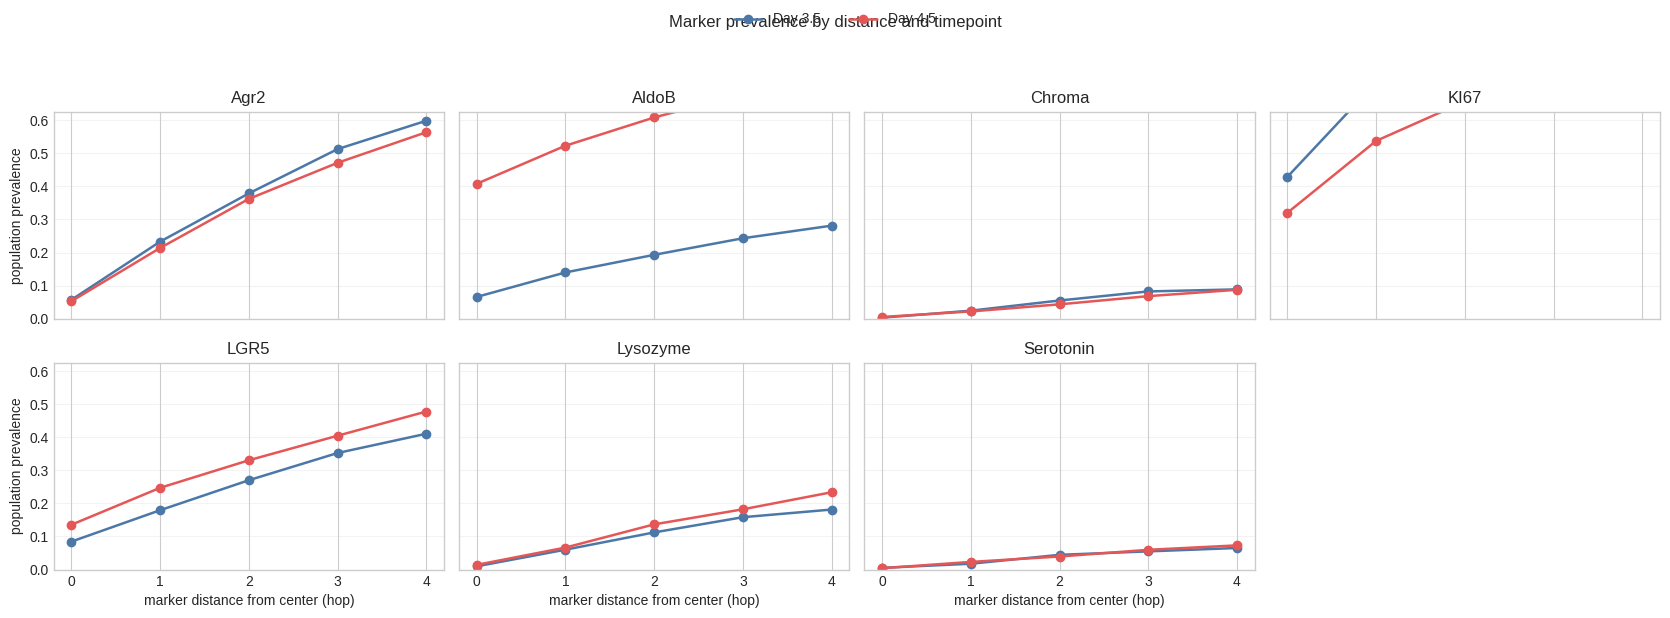

In [9]:
n_rows = int(np.ceil(len(marker_names) / N_PANEL_COLUMNS))
fig, axes = plt.subplots(
    n_rows,
    N_PANEL_COLUMNS,
    figsize=(4.2 * N_PANEL_COLUMNS, 3.1 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
axes_flat = axes.ravel()

for ax, marker in zip(axes_flat, marker_names):
    for timepoint in TIMEPOINT_ORDER:
        marker_df = prevalence_summary_df[
            (prevalence_summary_df["marker"] == marker)
            & (prevalence_summary_df["timepoint"] == timepoint)
        ].sort_values("hop")
        ax.plot(
            marker_df["hop"],
            marker_df["prevalence"],
            marker="o",
            linewidth=1.8,
            color=TIMEPOINT_COLORS[timepoint],
            label=timepoint,
        )
    ax.set_title(marker)
    ax.set_xticks(range(model_depth + 1))
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.22)

for ax in axes_flat[len(marker_names):]:
    ax.set_visible(False)
for row in range(n_rows):
    axes[row, 0].set_ylabel("population prevalence")
for ax in axes[-1]:
    if ax.get_visible():
        ax.set_xlabel("marker distance from center (hop)")

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="outside upper center",
    ncol=len(TIMEPOINT_ORDER),
    frameon=False,
)
fig.suptitle("Marker prevalence by distance and timepoint")
fig.tight_layout(rect=[0, 0, 1, 0.93])
save_figure(fig, "population_marker_prevalence_timepoint_comparison")
plt.show()

## Lineage Removal / Marker Isolation

This section loads saved outputs from `lineage_removal.ipynb` and recreates the region-wise MSE figures from the stored summary tables. It does not load graph data or trained models.

In [ ]:
REQUIRED_LINEAGE_TABLES = {
    "mse": "mse_summary_across_organoids.csv",
    "baseline": "global_baseline_summary_across_organoids.csv",
    "zero_counts": "marker_zero_counts.csv",
    "training": "training_summary.csv",
}


def is_complete_lineage_run(run_dir):
    run_dir = Path(run_dir)
    try:
        settings = load_json(result_settings_path(run_dir))
    except (FileNotFoundError, json.JSONDecodeError):
        return False
    tables_dir = run_dir / "tables"
    return all(
        (tables_dir / filename).exists()
        for filename in REQUIRED_LINEAGE_TABLES.values()
    )


def discover_latest_lineage_run():
    candidates = []
    if not LINEAGE_RESULTS_ROOT.exists():
        raise FileNotFoundError(LINEAGE_RESULTS_ROOT)
    for run_dir in LINEAGE_RESULTS_ROOT.iterdir():
        if not run_dir.is_dir() or not is_complete_lineage_run(run_dir):
            continue
        settings = load_json(result_settings_path(run_dir))
        split_mode = settings.get("split", {}).get("analysis_mode")
        analysis_variant = settings.get("analysis_variant")
        if LINEAGE_REQUIRE_FOLDED and split_mode != "folded":
            continue
        if (
            LINEAGE_ANALYSIS_VARIANT is not None
            and analysis_variant != LINEAGE_ANALYSIS_VARIANT
        ):
            continue
        candidates.append(run_dir)
    if not candidates:
        raise FileNotFoundError("No complete lineage_removal run found.")
    return max(candidates, key=lambda path: path.stat().st_mtime)


def load_lineage_run(run_dir):
    run_dir = Path(run_dir).expanduser().resolve()
    settings_path = result_settings_path(run_dir)
    settings = load_json(settings_path)
    tables = {
        key: pd.read_csv(run_dir / "tables" / filename)
        for key, filename in REQUIRED_LINEAGE_TABLES.items()
    }
    return {
        "run_dir": run_dir,
        "settings_path": settings_path,
        "settings": settings,
        "tables": tables,
    }


lineage_run_dir = (
    discover_latest_lineage_run()
    if LINEAGE_RUN_DIR is None
    else Path(LINEAGE_RUN_DIR).expanduser().resolve()
)
lineage_run = load_lineage_run(lineage_run_dir)
lineage_settings = lineage_run["settings"]
lineage_mse_df = lineage_run["tables"]["mse"].copy()
lineage_baseline_df = lineage_run["tables"]["baseline"].copy()
lineage_zero_counts_df = lineage_run["tables"]["zero_counts"].copy()
lineage_training_df = lineage_run["tables"]["training"].copy()

lineage_mse_df.insert(0, "run_dir", str(lineage_run["run_dir"]))
lineage_baseline_df.insert(0, "run_dir", str(lineage_run["run_dir"]))
lineage_zero_counts_df.insert(0, "run_dir", str(lineage_run["run_dir"]))
lineage_training_df.insert(0, "run_dir", str(lineage_run["run_dir"]))

lineage_mse_df.to_csv(
    TABLES_DIR / "lineage_mse_summary_across_organoids.csv", index=False
)
lineage_baseline_df.to_csv(
    TABLES_DIR / "lineage_global_baseline_summary_across_organoids.csv",
    index=False,
)
lineage_zero_counts_df.to_csv(
    TABLES_DIR / "lineage_marker_zero_counts.csv", index=False
)
lineage_training_df.to_csv(
    TABLES_DIR / "lineage_training_summary.csv", index=False
)

lineage_run_summary_df = pd.DataFrame([{
    "run_dir": str(lineage_run["run_dir"]),
    "analysis_variant": lineage_settings.get("analysis_variant"),
    "analysis_mode": lineage_settings.get("split", {}).get("analysis_mode"),
    "timepoint_filter_mode": lineage_settings.get("filtering", {}).get(
        "timepoint_filter_mode"
    ),
    "model_depths": repr(lineage_settings.get("model", {}).get("depths")),
    "n_removal_sets": len(lineage_settings.get("removal_sets", [])),
    "n_graphs_after_filtering": lineage_settings.get("filtering", {}).get(
        "n_graphs_after_filtering"
    ),
}])
lineage_run_summary_df.to_csv(
    TABLES_DIR / "lineage_run_summary.csv", index=False
)
display(lineage_run_summary_df)
display(lineage_mse_df.head(12))

In [ ]:
LINEAGE_COMBO_ORDER = ["orig_orig", "orig_reduced", "reduced_reduced"]
LINEAGE_COMBO_STYLE = {
    "orig_orig": {
        "label": "orig/orig",
        "color": "#2f6f9f",
        "marker": "o",
        "linestyle": "-",
    },
    "orig_reduced": {
        "label": "orig/reduced",
        "color": "#c65f32",
        "marker": "s",
        "linestyle": "--",
    },
    "reduced_reduced": {
        "label": "reduced/reduced",
        "color": "#3f8664",
        "marker": "^",
        "linestyle": "-.",
    },
}


def lineage_removal_sets_from_results():
    settings_sets = lineage_settings.get("removal_sets") or []
    if settings_sets:
        return [
            {
                "key": spec.get("key"),
                "label": spec.get("label", spec.get("key")),
                "markers": spec.get("markers"),
                "keep_markers": spec.get("keep_markers"),
            }
            for spec in settings_sets
        ]
    ordered = (
        lineage_mse_df[["removal_key", "removal_label"]]
        .drop_duplicates()
        .rename(columns={"removal_key": "key", "removal_label": "label"})
    )
    return ordered.to_dict(orient="records")


LINEAGE_REMOVAL_SETS = lineage_removal_sets_from_results()
LINEAGE_MODEL_DEPTHS = sorted(
    lineage_mse_df["depth"].dropna().astype(int).unique().tolist()
)
LINEAGE_REGION_ORDER_EFFECTIVE = [
    region
    for region in LINEAGE_REGION_ORDER
    if region in set(lineage_mse_df["region"])
]
if not LINEAGE_REGION_ORDER_EFFECTIVE:
    LINEAGE_REGION_ORDER_EFFECTIVE = sorted(lineage_mse_df["region"].unique())


def plot_lineage_region_mse(region):
    region_df = lineage_mse_df[lineage_mse_df["region"] == region]
    baseline_row = lineage_baseline_df[
        lineage_baseline_df["region"] == region
    ]
    if baseline_row.empty:
        raise ValueError(f"No global baseline result for region {region!r}.")
    baseline_mean = float(baseline_row.iloc[0]["mean_mse"])
    baseline_sem = float(baseline_row.iloc[0]["sem_mse"])

    n_panels = len(LINEAGE_REMOVAL_SETS)
    n_cols = 4
    n_rows = int(np.ceil(max(n_panels, 1) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.9 * n_cols, 3.45 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )
    axes_flat = axes.ravel()
    legend_handles = []
    legend_labels = []
    baseline_line = None

    for panel_idx, (ax, spec) in enumerate(
        zip(axes_flat, LINEAGE_REMOVAL_SETS)
    ):
        panel = region_df[region_df["removal_key"] == spec["key"]]
        for combo in LINEAGE_COMBO_ORDER:
            style = LINEAGE_COMBO_STYLE[combo]
            curve = (
                panel[panel["train_eval_key"] == combo]
                .sort_values("depth")
            )
            if curve.empty:
                continue
            x = curve["depth"].to_numpy(dtype=float)
            y = curve["mean_mse"].to_numpy(dtype=float)
            sem = curve["sem_mse"].to_numpy(dtype=float)
            line, = ax.plot(
                x,
                y,
                color=style["color"],
                marker=style["marker"],
                linestyle=style["linestyle"],
                linewidth=2.0,
                markersize=5,
                label=style["label"],
            )
            valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(sem)
            if np.any(valid):
                ax.fill_between(
                    x[valid],
                    y[valid] - sem[valid],
                    y[valid] + sem[valid],
                    color=style["color"],
                    alpha=0.18,
                    linewidth=0,
                )
            if panel_idx == 0:
                legend_handles.append(line)
                legend_labels.append(style["label"])

        baseline_line = ax.axhline(
            baseline_mean,
            color="#4a4a4a",
            linestyle=":",
            linewidth=1.8,
            label="Global baseline",
        )
        ax.axhspan(
            baseline_mean - baseline_sem,
            baseline_mean + baseline_sem,
            color="#6b6b6b",
            alpha=0.14,
            linewidth=0,
        )
        ax.set_title(spec["label"], fontsize=10)
        ax.set_xticks(LINEAGE_MODEL_DEPTHS)
        ax.set_xlabel("Model depth")
        ax.set_ylabel("MSE")
        ax.grid(alpha=0.25)

    unused_axes = axes_flat[n_panels:]
    if baseline_line is not None:
        legend_handles.append(baseline_line)
        legend_labels.append("Global baseline")
    if len(unused_axes):
        legend_ax = unused_axes[0]
        legend_ax.set_axis_off()
        legend_ax.legend(
            legend_handles,
            legend_labels,
            loc="center",
            frameon=False,
        )
        for ax in unused_axes[1:]:
            ax.set_visible(False)
    else:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="outside lower center",
            ncol=min(4, len(legend_handles)),
        )

    fig.suptitle(
        f"Lineage removal: {region.capitalize()} region",
        fontsize=15,
        fontweight="bold",
    )
    save_figure(fig, f"lineage_removal_mse_{region}")
    plt.show()
    return fig, axes


lineage_region_figures = {
    region: plot_lineage_region_mse(region)
    for region in LINEAGE_REGION_ORDER_EFFECTIVE
}

### Depth-Specific Lineage Summary

For each region, this figure compares depth-specific MSE for the original model (`orig/orig`) and marker-reduced models trained and evaluated on reduced inputs (`reduced/reduced`). Conditions are sorted by ascending MSE. Horizontal error bars show SEM across organoids.


In [ ]:
LINEAGE_MARKER_DISPLAY_ORDER = [
    "LGR5",
    "KI67",
    "AldoB",
    "Lysozyme",
    "Agr2",
    "Serotonin",
    "Chroma",
    "Mucin 2",
    "Glucagon",
]
LINEAGE_MARKER_DISPLAY_NAMES = {
    "KI67": "Ki67",
    "Lysozyme": "Lyz",
    "Serotonin": "Sero",
}
LINEAGE_MARKER_NAMES = list(
    lineage_settings.get("dataset", {}).get("marker_names") or []
)
if not LINEAGE_MARKER_NAMES and not lineage_zero_counts_df.empty:
    LINEAGE_MARKER_NAMES = sorted(lineage_zero_counts_df["marker"].dropna().unique())


def _ordered_lineage_markers(markers):
    markers = [marker for marker in markers if marker in set(LINEAGE_MARKER_NAMES)]
    order = {marker: index for index, marker in enumerate(LINEAGE_MARKER_DISPLAY_ORDER)}
    return sorted(
        markers,
        key=lambda marker: (order.get(marker, len(order)), LINEAGE_MARKER_NAMES.index(marker)),
    )


def _lineage_marker_label(markers):
    markers = _ordered_lineage_markers(markers)
    if len(markers) == 0:
        return "No markers"
    if set(markers) == set(LINEAGE_MARKER_NAMES):
        return "All markers"
    if len(markers) == 6 and len(markers) == len(LINEAGE_MARKER_NAMES) - 1:
        missing = [marker for marker in LINEAGE_MARKER_NAMES if marker not in set(markers)]
        return "all except " + "+".join(
            LINEAGE_MARKER_DISPLAY_NAMES.get(marker, marker)
            for marker in _ordered_lineage_markers(missing)
        )
    return "+".join(LINEAGE_MARKER_DISPLAY_NAMES.get(marker, marker) for marker in markers)


def lineage_present_marker_label(spec):
    if spec.get("key") == "original":
        return _lineage_marker_label(LINEAGE_MARKER_NAMES)
    keep_markers = spec.get("keep_markers")
    if keep_markers is not None:
        return _lineage_marker_label(list(keep_markers))
    removed_markers = spec.get("markers")
    if removed_markers is not None:
        removed = set(removed_markers)
        return _lineage_marker_label([
            marker for marker in LINEAGE_MARKER_NAMES if marker not in removed
        ])
    return spec.get("label", spec.get("key", "Unknown"))


def lineage_depth_point_table(region, depth):
    rows = []
    region_depth = lineage_mse_df[
        (lineage_mse_df["region"] == region)
        & (lineage_mse_df["depth"].astype(float) == float(depth))
    ]
    original = region_depth[region_depth["train_eval_key"] == "orig_orig"]
    if original.empty:
        raise ValueError(f"No orig/orig result for region={region!r}, depth={depth}.")
    original_row = original.iloc[0]
    rows.append({
        "region": region,
        "depth": int(depth),
        "condition_key": "original",
        "plot_label": lineage_present_marker_label({"key": "original"}),
        "removal_key": "original",
        "removal_label": "Original",
        "train_eval_key": "orig_orig",
        "mean_mse": float(original_row["mean_mse"]),
        "sem_mse": float(original_row["sem_mse"]),
        "row_type": "original",
    })

    for spec in LINEAGE_REMOVAL_SETS:
        reduced = region_depth[
            (region_depth["removal_key"] == spec["key"])
            & (region_depth["train_eval_key"] == "reduced_reduced")
        ]
        if not reduced.empty:
            reduced_row = reduced.iloc[0]
            rows.append({
                "region": region,
                "depth": int(depth),
                "condition_key": spec["key"],
                "plot_label": lineage_present_marker_label(spec),
                "removal_key": spec["key"],
                "removal_label": spec["label"],
                "train_eval_key": "reduced_reduced",
                "mean_mse": float(reduced_row["mean_mse"]),
                "sem_mse": float(reduced_row["sem_mse"]),
                "row_type": "reduced_reduced",
            })
    return pd.DataFrame(rows)


lineage_depth_point_df = pd.concat(
    [
        lineage_depth_point_table(region, LINEAGE_POINT_DEPTH)
        for region in LINEAGE_REGION_ORDER_EFFECTIVE
    ],
    ignore_index=True,
)
lineage_depth_point_df.to_csv(
    TABLES_DIR / f"lineage_depth{LINEAGE_POINT_DEPTH}_point_summary.csv",
    index=False,
)


def plot_lineage_depth_point_summary_for_region(region, depth):
    plot_df = lineage_depth_point_df[
        lineage_depth_point_df["region"] == region
    ].copy()

    def _condition_sort_value(group):
        for row_type in ("reduced_reduced", "original"):
            subset = group[group["row_type"] == row_type]
            if not subset.empty:
                return float(subset.iloc[0]["mean_mse"])
        return float(group["mean_mse"].iloc[0])

    condition_order = (
        plot_df.groupby("condition_key", sort=False)
        .apply(lambda group: pd.Series({
            "plot_label": group["plot_label"].iloc[0],
            "sort_mse": _condition_sort_value(group),
        }))
        .sort_values("sort_mse", ascending=True)
        .reset_index()
    )
    labels = condition_order["plot_label"].tolist()
    y = np.arange(len(labels), dtype=float)
    y_lookup = dict(zip(condition_order["condition_key"], y))
    plot_df["plot_y"] = plot_df["condition_key"].map(y_lookup)
    baseline_row = lineage_baseline_df[
        lineage_baseline_df["region"] == region
    ].iloc[0]
    baseline_mean = float(baseline_row["mean_mse"])
    baseline_sem = float(baseline_row["sem_mse"])

    fig, ax = plt.subplots(
        figsize=(3.3, 0.28 * len(labels) + 1.0),
        constrained_layout=True,
    )
    ax.axvspan(
        baseline_mean - baseline_sem,
        baseline_mean + baseline_sem,
        color="#6b6b6b",
        alpha=0.16,
        linewidth=0,
    )
    ax.axvline(
        baseline_mean,
        color="#4a4a4a",
        linestyle="--",
        linewidth=1.6,
    )
    ax.text(
        baseline_mean,
        0.96,
        "baseline",
        transform=ax.get_xaxis_transform(),
        rotation=90,
        ha="right",
        va="top",
        color="#4a4a4a",
        fontsize=9,
    )

    original_mask = plot_df["row_type"] == "original"
    reduced_mask = plot_df["row_type"] == "reduced_reduced"
    y_offsets = {
        "reduced_reduced": 0.12,
        "original": 0.0,
    }
    ax.errorbar(
        plot_df.loc[reduced_mask, "mean_mse"],
        plot_df.loc[reduced_mask, "plot_y"] + y_offsets["reduced_reduced"],
        xerr=plot_df.loc[reduced_mask, "sem_mse"],
        fmt="o",
        color="#3f8664",
        ecolor="#3f8664",
        elinewidth=1.4,
        capsize=3,
        markersize=5,
    )
    ax.errorbar(
        plot_df.loc[original_mask, "mean_mse"],
        plot_df.loc[original_mask, "plot_y"] + y_offsets["original"],
        xerr=plot_df.loc[original_mask, "sem_mse"],
        fmt="D",
        color="#2f6f9f",
        ecolor="#2f6f9f",
        elinewidth=1.4,
        capsize=3,
        markersize=5,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("MSE")
    ax.set_ylabel("")
    ax.text(
        -0.02,
        1.02,
        "Markers used",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=plt.rcParams["ytick.labelsize"],
        fontweight="bold",
        clip_on=False,
    )
    ax.grid(axis="x", alpha=0.25)
    ax.set_title(
        region,
        fontsize=13,
        fontweight="bold",
    )
    save_figure(fig, f"lineage_depth{depth}_mse_point_summary_{region}")
    plt.show()
    return fig, ax


lineage_depth_point_figures = {
    region: plot_lineage_depth_point_summary_for_region(
        region,
        LINEAGE_POINT_DEPTH,
    )
    for region in LINEAGE_REGION_ORDER_EFFECTIVE
}
display(lineage_depth_point_df)


### Focused Full-Region Lineage Curves

This compact figure compares the all-marker model with the LGR5-only and without-LGR5 reduced/reduced conditions in the full-region evaluation.


In [ ]:
FOCUSED_LINEAGE_REGION = "full"


def find_lineage_removal_spec(predicate, description):
    matches = [spec for spec in LINEAGE_REMOVAL_SETS if predicate(spec)]
    if not matches:
        raise ValueError(f"Could not find lineage removal set for {description}.")
    return matches[0]


def lineage_curve_table(region, train_eval_key, removal_key=None):
    mask = (
        (lineage_mse_df["region"] == region)
        & (lineage_mse_df["train_eval_key"] == train_eval_key)
    )
    if removal_key is not None:
        mask &= lineage_mse_df["removal_key"] == removal_key
    curve = lineage_mse_df.loc[mask].copy()
    if curve.empty:
        raise ValueError(
            f"No lineage curve rows for region={region!r}, "
            f"train_eval_key={train_eval_key!r}, removal_key={removal_key!r}."
        )
    curve["depth"] = curve["depth"].astype(int)
    # orig/orig is duplicated across removal settings in the saved table; keep
    # one value per depth after checking the grouping level.
    return (
        curve.groupby("depth", as_index=False)
        .agg(mean_mse=("mean_mse", "first"), sem_mse=("sem_mse", "first"))
        .sort_values("depth")
    )


lgr5_only_spec = find_lineage_removal_spec(
    lambda spec: set(spec.get("keep_markers") or []) == {"LGR5"},
    "LGR5 only",
)
without_lgr5_spec = find_lineage_removal_spec(
    lambda spec: set(spec.get("markers") or []) == {"LGR5"},
    "without LGR5",
)

focused_lineage_curves = [
    {
        "label": "All markers",
        "curve": lineage_curve_table(FOCUSED_LINEAGE_REGION, "orig_orig"),
        "color": "#2f6f9f",
        "marker": "D",
    },
    {
        "label": "only LGR5",
        "curve": lineage_curve_table(
            FOCUSED_LINEAGE_REGION,
            "reduced_reduced",
            lgr5_only_spec["key"],
        ),
        "color": "#3f8664",
        "marker": "o",
    },
    {
        "label": lineage_present_marker_label(without_lgr5_spec),
        "curve": lineage_curve_table(
            FOCUSED_LINEAGE_REGION,
            "reduced_reduced",
            without_lgr5_spec["key"],
        ),
        "color": "#c65f32",
        "marker": "s",
    },
]

focused_baseline_row = lineage_baseline_df[
    lineage_baseline_df["region"] == FOCUSED_LINEAGE_REGION
].iloc[0]
focused_baseline_mean = float(focused_baseline_row["mean_mse"])
focused_baseline_sem = float(focused_baseline_row["sem_mse"])

fig, ax = plt.subplots(figsize=(2.25, 4.5), constrained_layout=True)
ax.axhspan(
    focused_baseline_mean - focused_baseline_sem,
    focused_baseline_mean + focused_baseline_sem,
    color="#6b6b6b",
    alpha=0.16,
    linewidth=0,
)
ax.axhline(
    focused_baseline_mean,
    color="#4a4a4a",
    linestyle="--",
    linewidth=1.4,
    label="baseline",
)
for item in focused_lineage_curves:
    curve = item["curve"]
    x = curve["depth"].to_numpy(float)
    y = curve["mean_mse"].to_numpy(float)
    sem = curve["sem_mse"].to_numpy(float)
    ax.plot(
        x,
        y,
        color=item["color"],
        marker=item["marker"],
        linewidth=1.8,
        markersize=5,
        label=item["label"],
    )
    ax.fill_between(
        x,
        y - sem,
        y + sem,
        color=item["color"],
        alpha=0.18,
        linewidth=0,
    )

ax.set_xticks(LINEAGE_MODEL_DEPTHS)
ax.set_xlabel("Model depth")
ax.set_ylabel("MSE")
ax.set_title("Full-region lineage curves", fontsize=12, fontweight="bold")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8, loc="best")
save_figure(fig, "lineage_focused_full_region_curves")
plt.show()


In [ ]:
if not lineage_zero_counts_df.empty:
    zero_summary = (
        lineage_zero_counts_df
        .groupby(["removal_label", "marker"], as_index=False)
        [["train_positive_values_zeroed", "val_positive_values_zeroed"]]
        .sum()
    )
    display(zero_summary)

## Save Plotting Configuration

In [ ]:
plotting_settings = {
    "created_at": datetime.now().isoformat(),
    "notebook": "experiments/plot_experiment_results.ipynb",
    "ablation_runs": {
        timepoint: str(run["run_dir"])
        for timepoint, run in ablation_runs.items()
    },
    "timepoint_modes": ABLATION_TIMEPOINT_MODES,
    "timepoint_order": TIMEPOINT_ORDER,
    "timepoint_colors": TIMEPOINT_COLORS,
    "require_folded": AUTO_DISCOVERY_REQUIRE_FOLDED,
    "require_matched_model_depth": REQUIRE_MATCHED_MODEL_DEPTH,
    "model_depth": model_depth,
    "marker_names": marker_names,
    "metrics": METRICS,
    "heatmap_min_cases_override": HEATMAP_MIN_CASES,
    "lineage_run": str(lineage_run["run_dir"]),
    "lineage_analysis_variant": lineage_settings.get("analysis_variant"),
    "lineage_regions": LINEAGE_REGION_ORDER_EFFECTIVE,
    "lineage_point_depth": LINEAGE_POINT_DEPTH,
    "save_dir": str(SAVE_DIR),
}
with (SAVE_DIR / "settings.json").open("w") as handle:
    json.dump(plotting_settings, handle, indent=2)

print(f"Saved comparison figures, combined tables, and settings to {SAVE_DIR}")

## Further Experiments

Add later result loaders and plotting sections below this point. The helper functions above intentionally operate on saved tables and settings rather than experiment-specific model objects.